In [22]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import smarts_cerebellum.globals as gl

reds = 'tomato'
blues = 'steelblue'

## Modulated WM volume

**note**: mod WM had convergence warning (for all groups, both left, right CST)

In [23]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'WM'

# obs means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')

# pred means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')

# confidence intervals (95th percentile)
patients_lme['e_lower'] = patients_lme['beta'] - patients_lme['ci_lower']
patients_lme['e_upper'] = patients_lme['ci_upper'] - patients_lme['beta']

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[0]
controls_lme['hemisphere'] = controls_lme.regionname.str[0]
patients_actual['hemisphere'] = patients_actual.regionname.str[0]
controls_actual['hemisphere'] = controls_actual.regionname.str[0]

left_patients_lme = patients_lme[patients_lme.hemisphere == 'l'].sort_values('Week')
left_patients_actual = patients_actual[patients_actual.hemisphere == 'l'].sort_values('Week')
left_controls_lme = controls_lme[controls_lme.hemisphere == 'l'].sort_values('Week')
left_controls_actual = controls_actual[controls_actual.hemisphere == 'l'].sort_values('Week')

right_patients_lme = patients_lme[patients_lme.hemisphere == 'r'].sort_values('Week')
right_patients_actual = patients_actual[patients_actual.hemisphere == 'r'].sort_values('Week')
right_controls_lme = controls_lme[controls_lme.hemisphere == 'r'].sort_values('Week')
right_controls_actual = controls_actual[controls_actual.hemisphere == 'r'].sort_values('Week')

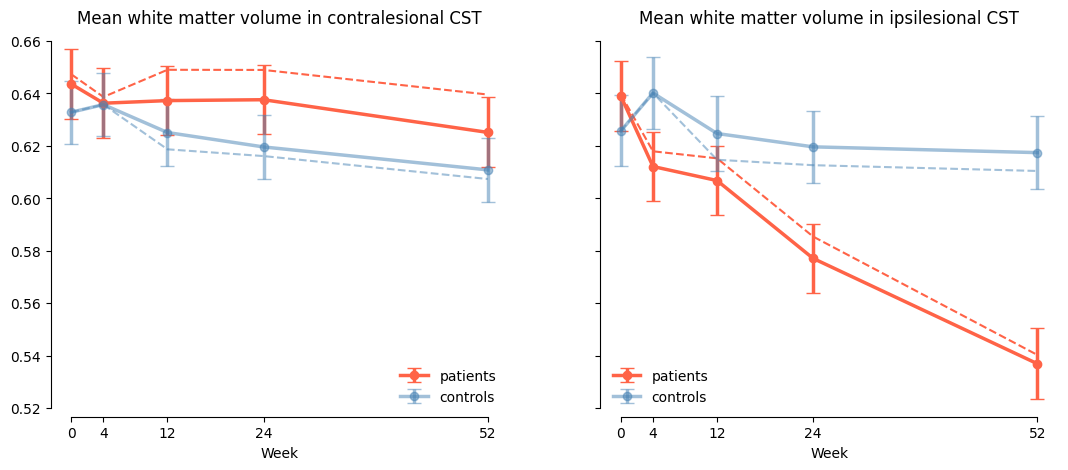

In [24]:
fig, ax = plt.subplots(1,2, figsize=(13,5), sharey = True)

# left hemisphere

ax[0].errorbar(x=left_patients_lme['Week'], y=left_patients_lme['beta'], yerr = left_patients_lme['se'], fmt = '-o', color = reds, capsize = 5, linewidth = 2.5, elinewidth = 2.5, label = 'patients')
ax[0].plot(left_patients_actual['Week'], left_patients_actual['mean'], color = reds, linestyle = '--')

ax[0].errorbar(x=left_controls_lme['Week'], y=left_controls_lme['beta'], yerr = left_controls_lme['se'], fmt = '-o', color = blues, capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.5, label = 'controls')
ax[0].plot(left_controls_actual['Week'], left_controls_actual['mean'], color = blues, linestyle = '--', alpha = 0.5)


ax[0].set_title("Mean white matter volume in contralesional CST")
#ax[0].set_title(f'mean  {segment} - contralesional')
ax[0].legend(loc = 'lower right', frameon = False)



# right hemisphere

ax[1].errorbar(x=right_patients_lme['Week'], y=right_patients_lme['beta'], yerr = right_patients_lme['se'], fmt = '-o', color = reds, capsize = 5, linewidth = 2.5, elinewidth = 2.5, label = 'patients')
ax[1].plot(right_patients_actual['Week'], right_patients_actual['mean'], color = reds, linestyle = '--')

ax[1].errorbar(x=right_controls_lme['Week'], y=right_controls_lme['beta'], yerr = right_controls_lme['se'], fmt = '-o', color = blues, capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.5, label = 'controls')
ax[1].plot(right_controls_actual['Week'], right_controls_actual['mean'], color = blues, linestyle = '--', alpha = 0.5)

ax[1].set_title("Mean white matter volume in ipsilesional CST")
#ax[1].set_title(f'lme betas for {segment} - RIGHT')
ax[1].legend(loc = 'lower left', frameon = False)

weeks = [0, 4, 12, 24, 52]
for i in range(2):
    ax[i].set_xticks(weeks)
    ax[i].set_xlabel("Week")
    
sns.despine(trim = True)
plt.show()

## T1

In [25]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'T1'

# obs means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mean.tsv'), sep = '\t')

# pred means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_CST_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_CST_lme.tsv'), sep = '\t')


# confidence intervals (95th percentile)
patients_lme['e_lower'] = patients_lme['beta'] - patients_lme['ci_lower']
patients_lme['e_upper'] = patients_lme['ci_upper'] - patients_lme['beta']

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[0]
controls_lme['hemisphere'] = controls_lme.regionname.str[0]
patients_actual['hemisphere'] = patients_actual.regionname.str[0]
controls_actual['hemisphere'] = controls_actual.regionname.str[0]

left_patients_lme = patients_lme[patients_lme.hemisphere == 'l'].sort_values('Week')
left_patients_actual = patients_actual[patients_actual.hemisphere == 'l'].sort_values('Week')
left_controls_lme = controls_lme[controls_lme.hemisphere == 'l'].sort_values('Week')
left_controls_actual = controls_actual[controls_actual.hemisphere == 'l'].sort_values('Week')

right_patients_lme = patients_lme[patients_lme.hemisphere == 'r'].sort_values('Week')
right_patients_actual = patients_actual[patients_actual.hemisphere == 'r'].sort_values('Week')
right_controls_lme = controls_lme[controls_lme.hemisphere == 'r'].sort_values('Week')
right_controls_actual = controls_actual[controls_actual.hemisphere == 'r'].sort_values('Week')

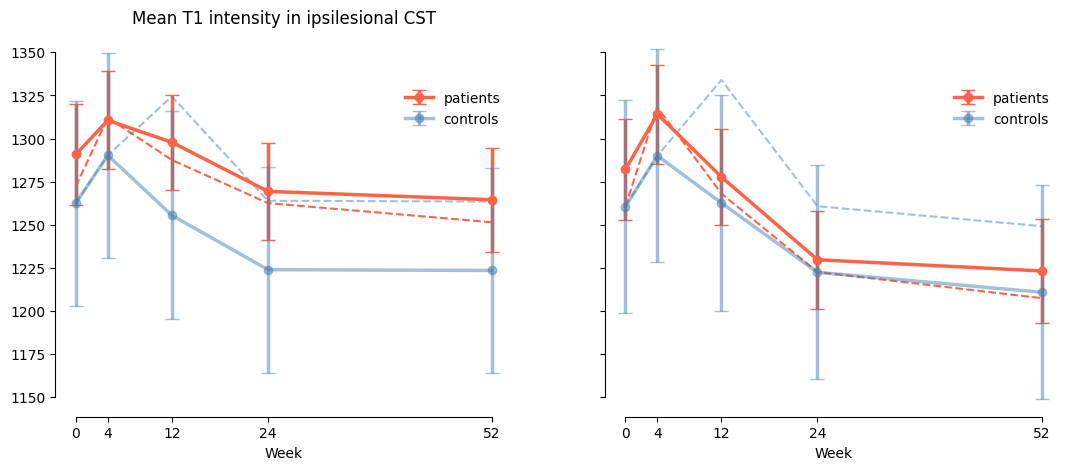

In [26]:
fig, ax = plt.subplots(1,2, figsize=(13,5), sharey = True)

# left hemisphere

ax[0].errorbar(x=left_patients_lme['Week'], y=left_patients_lme['beta'], yerr = left_patients_lme['se'], fmt = '-o', color = reds, capsize = 5, linewidth = 2.5, elinewidth = 2.5, label = 'patients')
ax[0].plot(left_patients_actual['Week'], left_patients_actual['mean'], color = reds, linestyle = '--')

ax[0].errorbar(x=left_controls_lme['Week'], y=left_controls_lme['beta'], yerr = left_controls_lme['se'], fmt = '-o', color = blues, capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.5, label = 'controls')
ax[0].plot(left_controls_actual['Week'], left_controls_actual['mean'], color = blues, linestyle = '--', alpha = 0.5)

ax[0].set_title("Mean T1 intensity in contralesional CST")
#ax[0].set_title(f'lme betas for {segment} - LEFT')
ax[0].legend(bbox_to_anchor = (1,.8), loc = 'center right', frameon = False)



# right hemisphere

ax[1].errorbar(x=right_patients_lme['Week'], y=right_patients_lme['beta'], yerr = right_patients_lme['se'], fmt = '-o', color = reds, capsize = 5, linewidth = 2.5, elinewidth = 2.5, label = 'patients')
ax[1].plot(right_patients_actual['Week'], right_patients_actual['mean'], color = reds, linestyle = '--')

ax[1].errorbar(x=right_controls_lme['Week'], y=right_controls_lme['beta'], yerr = right_controls_lme['se'], fmt = '-o', color = blues, capsize = 5, linewidth = 2.5, elinewidth = 2.5, alpha = 0.5, label = 'controls')
ax[1].plot(right_controls_actual['Week'], right_controls_actual['mean'], color = blues, linestyle = '--', alpha = 0.5)

ax[0].set_title("Mean T1 intensity in ipsilesional CST")
#ax[1].set_title(f'lme betas for {segment} - RIGHT')
ax[1].legend(bbox_to_anchor = (1,.8), loc = 'center right', frameon = False)

weeks = [0, 4, 12, 24, 52]
for i in range(2):
    ax[i].set_xticks(weeks)
    ax[i].set_xlabel("Week")
    

sns.despine(trim = True)
plt.show()